In [3]:
!pip install av

In [ ]:
!pip show mmaction2
!pip show mmcv-full

In [7]:
!pip uninstall mmaction2 -y
!pip install mmaction2==0.27.0

Found existing installation: mmaction2 0.24.1
Uninstalling mmaction2-0.24.1:
  Successfully uninstalled mmaction2-0.24.1


ERROR: Could not find a version that satisfies the requirement mmaction2==0.27.0 (from versions: 0.5.0, 0.6.0, 0.7.0, 0.8.0, 0.9.0, 0.10.0, 0.11.0, 0.12.0, 0.13.0, 0.14.0, 0.15.0, 0.16.0, 0.17.0, 0.18.0, 0.19.0, 0.20.0, 0.21.0, 0.22.0, 0.23.0, 0.24.0, 0.24.1, 1.0.0rc0, 1.0.0rc1, 1.0.0rc2, 1.0.0rc3, 1.0.0, 1.1.0, 1.2.0)
ERROR: No matching distribution found for mmaction2==0.27.0


### 영상데이터 준비

테스트

In [8]:
import sys
import importlib
from pathlib import Path

UTILS_DIR = Path(r"C:\4_1_딥러닝_팀플")  # aihub_mtfl_prepare_utils.py가 있는 폴더

if str(UTILS_DIR) not in sys.path:
    sys.path.append(str(UTILS_DIR))

import aihub_mtfl_prepare_utils as prep
importlib.reload(prep)

print(prep.__file__)

c:\4_1_딥러닝_팀플\aihub_mtfl_prepare_utils.py


In [11]:
AIHUB_TEST_ROOT = Path(r"C:\aihub_raw\assualt\12-1")
MTFL_TEST_OUT = Path(r"C:\4_1_딥러닝_팀플\MTFL_custom_12_2")

result, train_items, test_items, skipped = prep.prepare_aihub_for_mtfl(
    aihub_raw_root=AIHUB_TEST_ROOT,
    mtfl_custom_root=MTFL_TEST_OUT,
    train_ratio=0.8,
    seed=42,
    copy_xml=False,
    annotation_mode="full",
)

prep.print_prepare_result(result)

AIHub -> MTFL prepare result
XML files      : 4
Usable videos  : 4
Skipped        : 0
Train          : 3
Test           : 1
Video out root : C:\4_1_딥러닝_팀플\MTFL_custom_12_2\videos
Train anno     : C:\4_1_딥러닝_팀플\MTFL_custom_12_2\annotations\train_anno.txt
Test anno      : C:\4_1_딥러닝_팀플\MTFL_custom_12_2\annotations\test_anno.txt
Summary csv    : C:\4_1_딥러닝_팀플\MTFL_custom_12_2\annotations\split_summary.csv
Skipped csv    : C:\4_1_딥러닝_팀플\MTFL_custom_12_2\annotations\skipped.csv


---------------

### 영상 해상도 낮추기

In [ ]:
import subprocess
from pathlib import Path
ffmpeg_path = Path(r"C:\Users\dongwon\anaconda3\envs\mtfl_swin\Library\bin\ffmpeg.exe")

input_dir = Path(r"C:\4_1_딥러닝_팀플\MTFL_custom_12_2\videos\assault")
output_dir = Path(r"C:\4_1_딥러닝_팀플\MTFL_custom_12_2\video_320\assualt")
output_dir.mkdir(parents=True, exist_ok=True)

video_exts = [".mp4", ".avi", ".mov", ".mkv", ".wmv"]
videos = [p for p in input_dir.iterdir() if p.suffix.lower() in video_exts]

print(f"찾은 영상 개수: {len(videos)}")

for idx, input_video in enumerate(videos, start=1):
    output_video = output_dir / input_video.name

    print(f"\n[{idx}/{len(videos)}] 변환 중: {input_video.name}")

    cmd = [
        str(ffmpeg_path),
        "-y",
        "-hide_banner",
        "-loglevel", "error",
        "-stats",
        "-i", str(input_video),
        "-vf", "scale=320:-2",
        "-r", "30",
        "-c:v", "mpeg4",
        "-preset", "fast",
        "-crf", "23",
        "-an",
        str(output_video)
    ]

    result = subprocess.run(
        cmd,
        capture_output=True,
        text=True,
        encoding="utf-8",
        errors="replace"
    )

    if result.returncode == 0:
        before_mb = input_video.stat().st_size / (1024 ** 2)
        after_mb = output_video.stat().st_size / (1024 ** 2)
        reduction = (1 - after_mb / before_mb) * 100

        print(f"성공: {before_mb:.2f} MB -> {after_mb:.2f} MB ({reduction:.2f}% 감소)")
    else:
        print("실패:", input_video.name)
        print(result.stderr[-1000:])

print("\n전체 변환 완료")
print("저장 위치:", output_dir)

In [ ]:
import sys
import subprocess
from pathlib import Path

MTFL_ROOT = Path(r"C:\4_1_딥러닝_팀플\MTFL")
CUSTOM_ROOT = Path(r"C:\4_1_딥러닝_팀플\MTFL_custom_12_2")

VIDEO_DIR = Path(r"C:\4_1_딥러닝_팀플\MTFL_custom_12_2\video_320\assault")

PRETRAINED_3D = Path(r"C:\4_1_딥러닝_팀플\MTFL_custom\swin_base_patch244_window877_kinetics400_22k.pth")

FEATURE_ROOT = CUSTOM_ROOT / "features"

for d in ["L8", "L32", "L64"]:
    (FEATURE_ROOT / d).mkdir(parents=True, exist_ok=True)

In [13]:
for clip_len in [8, 32, 64]:
    save_dir = FEATURE_ROOT

    cmd = [
        sys.executable,
        str(MTFL_ROOT / "utils" / "feature_extractor.py"),
        "--clip_length", str(clip_len),
        "--dataset_path", str(VIDEO_DIR),
        "--save_dir", str(save_dir),
        "--pretrained_3d", str(PRETRAINED_3D),
        "--gpu", "0",
        "--batch_size", "4",
        "--num_workers", "0",
    ]

    print(f"\n===== Extracting L{clip_len} =====")
    print(" ".join(cmd))

    result = subprocess.run(
        cmd,
        cwd=str(MTFL_ROOT),
        capture_output=True,
        text=True,
        encoding="utf-8",
        errors="replace"
    )

    print("RETURN CODE:", result.returncode)
    print("\nSTDOUT:")
    print(result.stdout)
    print("\nSTDERR:")
    print(result.stderr)


===== Extracting L8 =====
c:\Users\dongwon\anaconda3\envs\mtfl_swin\python.exe C:\4_1_딥러닝_팀플\MTFL\utils\feature_extractor.py --clip_length 8 --dataset_path C:\4_1_딥러닝_팀플\MTFL_custom_12_2\video_320\assualt --save_dir C:\4_1_딥러닝_팀플\MTFL_custom_12_2\features\L8 --pretrained_3d C:\4_1_딥러닝_팀플\MTFL_custom\swin_base_patch244_window877_kinetics400_22k.pth --gpu 0 --batch_size 4 --num_workers 0
RETURN CODE: 0

STDOUT:
apex is not installed
2026-05-17 00:18:09,336 Found 4 unprocessed video files in C:\4_1_딥러닝_팀플\MTFL_custom_12_2\video_320\assualt
Found 4 video files in C:\4_1_딥러닝_팀플\MTFL_custom_12_2\video_320\assualt
load checkpoint from local path: C:\4_1_딥러닝_팀플\MTFL_custom\swin_base_patch244_window877_kinetics400_22k.pth
The model and loaded state dict do not match exactly

size mismatch for cls_head.fc_cls.weight: copying a param with shape torch.Size([400, 1024]) from checkpoint, the shape in current model is torch.Size([18, 1024]).
size mismatch for cls_head.fc_cls.bias: copying a param wi

In [ ]:
# import sys
# import subprocess
# from pathlib import Path

# MTFL_ROOT = "C:/4_1_딥러닝_팀플/MTFL"
# CUSTOM_ROOT = "C:/4_1_딥러닝_팀플/MTFL_custom"

# feature_script = f"{MTFL_ROOT}/utils/feature_extractor.py"
# video_dir = f"{CUSTOM_ROOT}/videos"
# feature_dir = f"{CUSTOM_ROOT}/features"
# weight_path = f"{CUSTOM_ROOT}/swin_base_patch244_window877_kinetics400_22k.pth"

# Path(feature_dir).mkdir(parents=True, exist_ok=True)

# for clip_length in [32, 64]:
#     print(f"\n========== Extracting L{clip_length} features ==========")

#     cmd = [
#         sys.executable,
#         feature_script,
#         "--clip_length", str(clip_length),
#         "--dataset_path", video_dir,
#         "--save_dir", feature_dir,
#         "--pretrained_3d", weight_path,
#     ]

#     result = subprocess.run(cmd, capture_output=True, text=True)

#     print("RETURN CODE:", result.returncode)
#     print("STDOUT:")
#     print(result.stdout)
#     print("STDERR:")
#     print(result.stderr)

#     if result.returncode != 0:
#         raise RuntimeError(f"L{clip_length} feature extraction failed")

### Feature 생성 확인(8/32/64)

In [ ]:
from pathlib import Path

for L in ["L8", "L32", "L64"]:
    files = list(Path(f"C:\4_1_딥러닝_팀플\MTFL_custom_12_2/{L}").rglob("*.txt"))
    print(L, len(files))
    for f in files[:3]:
        print(" ", f)

### ~~Detection model 학습~~

In [ ]:
import sys
import subprocess
from pathlib import Path

MTFL_ROOT = "C:/4_1_딥러닝_팀플/MTFL"
CUSTOM_ROOT = "C:/4_1_딥러닝_팀플/MTFL_custom"

Path(f"{CUSTOM_ROOT}/checkpoints").mkdir(parents=True, exist_ok=True)
Path(f"{CUSTOM_ROOT}/train_results").mkdir(parents=True, exist_ok=True)

cmd = [
    sys.executable,
    f"{MTFL_ROOT}/detection/train.py",
    "--train_anno", f"{CUSTOM_ROOT}/annotations/train_anno.txt",
    "--test_anno", f"{CUSTOM_ROOT}/annotations/test_anno.txt",
    "--lf_dir", f"{CUSTOM_ROOT}/features/L64",
    "--mf_dir", f"{CUSTOM_ROOT}/features/L32",
    "--sf_dir", f"{CUSTOM_ROOT}/features/L8",
    "--save_models", f"{CUSTOM_ROOT}/checkpoints",
    "--output_dir", f"{CUSTOM_ROOT}/train_results",
]

result = subprocess.run(cmd, capture_output=True, text=True)

print("RETURN CODE:", result.returncode)
print(result.stdout)
print(result.stderr)

### 학습된 checkpoint 확인

### Detection test 확인

In [2]:
import sys
import subprocess
from pathlib import Path

MTFL_ROOT = Path(r"C:\4_1_딥러닝_팀플\MTFL")
CUSTOM_ROOT = Path(r"C:\4_1_딥러닝_팀플\MTFL_custom_12_2")

detection_model = Path(r"C:\4_1_딥러닝_팀플\MTFL_UCF_custom") / "checkpoints_common" / "MTFL-1480.pkl"

output_dir = CUSTOM_ROOT / "results_eval"
output_dir.mkdir(parents=True, exist_ok=True)

cmd = [
    sys.executable,
    str(MTFL_ROOT / "detection" / "test.py"),

    "--test_anno", str(CUSTOM_ROOT / "annotations" / "test_anno_assault_12_1.txt"),
    "--detection_model", str(detection_model),

    "--lf_dir", str(CUSTOM_ROOT / "features" / "L64"),
    "--mf_dir", str(CUSTOM_ROOT / "features" / "L32"),
    "--sf_dir", str(CUSTOM_ROOT / "features" / "L8"),

    "--output_dir", str(output_dir),
    "--gpu", "0",
    "--feature_size", "1024",
    "--seg_num", "32",
    "--workers", "0",
]

result = subprocess.run(
    cmd,
    cwd=str(MTFL_ROOT),
    capture_output=True,
    text=True,
    encoding="utf-8",
    errors="replace"
)

print("RETURN CODE:", result.returncode)
print("\n===== STDOUT =====")
print(result.stdout)
print("\n===== STDERR =====")
print(result.stderr)

RETURN CODE: 0

===== STDOUT =====

Overall auc : 0.4918358595157771, Average Precision : 0.5111470520008151



===== STDERR =====

100%|██████████| 4/4 [00:03<00:00,  1.14it/s]



### 결과 확인

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

CUSTOM_ROOT = Path(r"C:\4_1_딥러닝_팀플\MTFL_custom_12_2")
score_root = CUSTOM_ROOT / "results_eval" / "scores"

score_files = sorted(score_root.rglob("*_scores.npy"))

print("score files:", len(score_files))
for p in score_files[:10]:
    print(p)

score files: 4
C:\4_1_딥러닝_팀플\MTFL_custom_12_2\results_eval\scores\assault\12-1_cam01_assault01_place09_day_spring_scores.npy
C:\4_1_딥러닝_팀플\MTFL_custom_12_2\results_eval\scores\assault\12-1_cam01_assault01_place09_day_summer_scores.npy
C:\4_1_딥러닝_팀플\MTFL_custom_12_2\results_eval\scores\assault\12-1_cam02_assault01_place09_day_spring_scores.npy
C:\4_1_딥러닝_팀플\MTFL_custom_12_2\results_eval\scores\assault\12-1_cam02_assault01_place09_day_summer_scores.npy


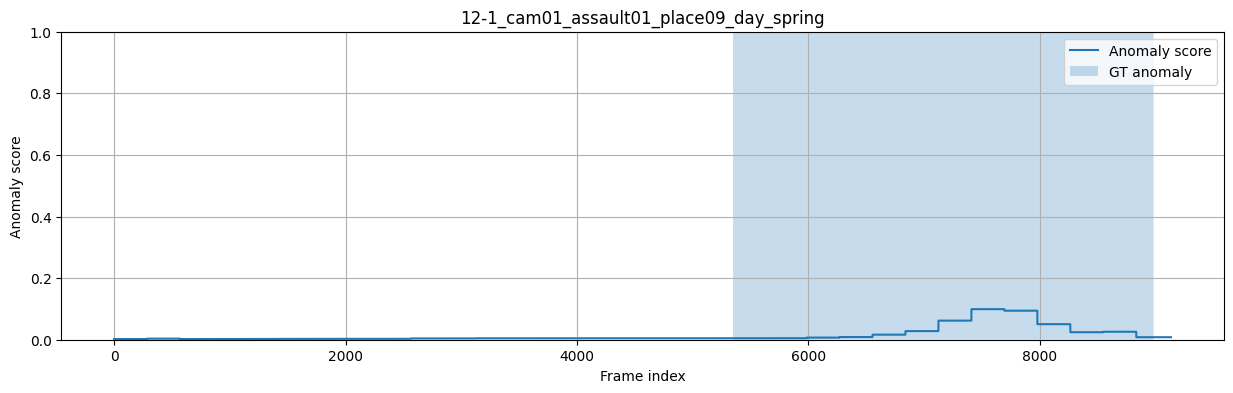

In [27]:
def plot_saved_score(score_path):
    score_path = Path(score_path)
    scores = np.load(score_path)

    gt_path = score_path.with_name(score_path.name.replace("_scores.npy", "_gt.npy"))
    gt = np.load(gt_path) if gt_path.exists() else None

    plt.figure(figsize=(15, 4))
    plt.plot(scores, label="Anomaly score")

    if gt is not None:
        anomaly_idx = np.where(gt == 1)[0]
        if len(anomaly_idx) > 0:
            plt.fill_between(
                np.arange(len(gt)),
                0,
                1,
                where=(gt == 1),
                alpha=0.25,
                label="GT anomaly"
            )

    plt.ylim(0, 1)
    plt.title(score_path.stem.replace("_scores", ""))
    plt.xlabel("Frame index")
    plt.ylabel("Anomaly score")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_saved_score(score_files[0])

In [7]:
def save_score_plot(score_path, save_dir):
    score_path = Path(score_path)
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    scores = np.load(score_path)

    gt_path = score_path.with_name(score_path.name.replace("_scores.npy", "_gt.npy"))
    gt = np.load(gt_path) if gt_path.exists() else None

    video_name = score_path.stem.replace("_scores", "")

    plt.figure(figsize=(15, 4))
    plt.plot(scores, label="Anomaly score")

    if gt is not None:
        plt.fill_between(
            np.arange(len(gt)),
            0,
            1,
            where=(gt == 1),
            alpha=0.25,
            label="GT anomaly"
        )

    plt.ylim(0, 1)
    plt.title(video_name)
    plt.xlabel("Frame index")
    plt.ylabel("Anomaly score")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    out_path = save_dir / f"{video_name}.png"
    plt.savefig(out_path, dpi=200)
    plt.close()

    return out_path

plot_save_dir = CUSTOM_ROOT / "qualitative_score_plots"

for score_path in score_files:
    out_path = save_score_plot(score_path, plot_save_dir)
    print("saved:", out_path)

saved: C:\4_1_딥러닝_팀플\MTFL_custom_12_2\qualitative_score_plots\12-1_cam01_assault01_place09_day_spring.png
saved: C:\4_1_딥러닝_팀플\MTFL_custom_12_2\qualitative_score_plots\12-1_cam01_assault01_place09_day_summer.png
saved: C:\4_1_딥러닝_팀플\MTFL_custom_12_2\qualitative_score_plots\12-1_cam02_assault01_place09_day_spring.png
saved: C:\4_1_딥러닝_팀플\MTFL_custom_12_2\qualitative_score_plots\12-1_cam02_assault01_place09_day_summer.png


In [12]:
def load_feature(path):
    path = Path(path)

    if path.suffix == ".npy":
        arr = np.load(path)
    else:
        arr = np.loadtxt(path)

    arr = np.asarray(arr, dtype=np.float32)

    # shape이 (T, C)라고 가정
    return arr

video_name = "Assault006_x264"
CUSTOM_ROOT = Path(r"C:\4_1_딥러닝_팀플\MTFL_UCF_custom")
lf_path = CUSTOM_ROOT / "features" / "L64" / "Assault" / f"{video_name}.txt"
mf_path = CUSTOM_ROOT / "features" / "L32" / "Assault" / f"{video_name}.txt"
sf_path = CUSTOM_ROOT / "features" / "L8" / "Assault" / f"{video_name}.txt"

lf = load_feature(lf_path)
mf = load_feature(mf_path)
sf = load_feature(sf_path)

print(lf.shape, mf.shape, sf.shape)

(32, 1024) (32, 1024) (32, 1024)


In [18]:
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
MTFL_ROOT = Path(r"C:\4_1_딥러닝_팀플\MTFL")
sys.path.append(str(MTFL_ROOT / "detection"))

from model import Model

In [14]:
def temporal_attribution(model, lf, mf, sf, target_idx=None, device="cuda"):
    model.eval()

    input1 = torch.tensor(lf, dtype=torch.float32, device=device).unsqueeze(0)
    input2 = torch.tensor(mf, dtype=torch.float32, device=device).unsqueeze(0)
    input3 = torch.tensor(sf, dtype=torch.float32, device=device).unsqueeze(0)

    input1.requires_grad_(True)
    input2.requires_grad_(True)
    input3.requires_grad_(True)

    score_abnormal, score_normal, feat_select_abn, feat_select_normal, scores = model(input1, input2, input3)

    scores_1d = scores.squeeze()  # T

    if target_idx is None:
        target_idx = int(torch.argmax(scores_1d).item())

    target_score = scores_1d[target_idx]

    model.zero_grad()
    target_score.backward()

    attr_lf = input1.grad.abs().mean(dim=2).detach().cpu().numpy().squeeze()
    attr_mf = input2.grad.abs().mean(dim=2).detach().cpu().numpy().squeeze()
    attr_sf = input3.grad.abs().mean(dim=2).detach().cpu().numpy().squeeze()

    return {
        "scores": scores_1d.detach().cpu().numpy(),
        "target_idx": target_idx,
        "attr_lf": attr_lf,
        "attr_mf": attr_mf,
        "attr_sf": attr_sf,
    }

In [15]:
def plot_temporal_attribution(result, title="Temporal attribution"):
    scores = result["scores"]
    target_idx = result["target_idx"]

    plt.figure(figsize=(15, 4))
    plt.plot(scores, label="Snippet anomaly score")
    plt.axvline(target_idx, linestyle="--", label=f"target snippet={target_idx}")
    plt.ylim(0, 1)
    plt.title(title)
    plt.xlabel("Snippet index")
    plt.ylabel("Score")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(15, 4))
    plt.plot(result["attr_lf"], label="L64 attribution")
    plt.plot(result["attr_mf"], label="L32 attribution")
    plt.plot(result["attr_sf"], label="L8 attribution")
    plt.title("Gradient attribution by temporal scale")
    plt.xlabel("Snippet index")
    plt.ylabel("Mean |gradient|")
    plt.grid(True)
    plt.legend()
    plt.show()

In [20]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

detection_model_path = Path(r"C:\4_1_딥러닝_팀플\MTFL_UCF_custom\checkpoints_common\MTFL-1480.pkl")

model = Model(feature_dim=1024, batch_size=1, seg_num=32)
state = torch.load(detection_model_path, map_location=device)
model.load_state_dict(state)
model.to(device)
model.eval()

Model(
  (Encoder): Encoder(
    (CVA1): CVA(
      (cross_attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
      )
    )
    (CVA2): CVA(
      (cross_attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
      )
    )
    (CVA3): CVA(
      (cross_attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
      )
    )
    (aggregate): Aggregate(
      (conv_1): Sequential(
        (0): Conv1d(1024, 512, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): LeakyReLU(negative_slope=0.05)
        (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (conv_2): Sequential(
        (0): Conv1d(1024, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
        (1): LeakyReLU(negative_slope=0.05)
  

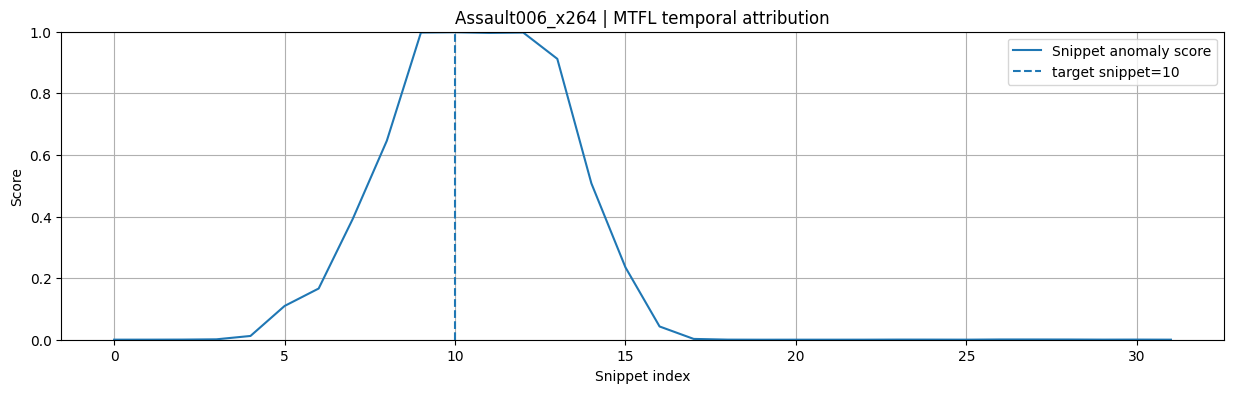

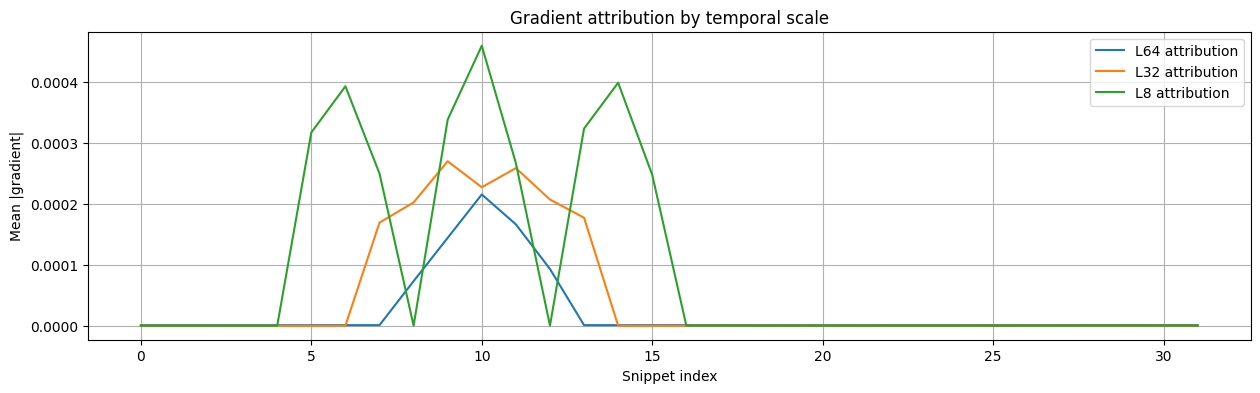

In [21]:
result_attr = temporal_attribution(
    model=model,
    lf=lf,
    mf=mf,
    sf=sf,
    target_idx=None,
    device=device
)

plot_temporal_attribution(
    result_attr,
    title=f"{video_name} | MTFL temporal attribution"
)